# Capstone: Predicting Next-Day Rain in Australia



Dataset: `weatherAUS_reduced.csv` — daily weather observations from 49 Australian
weather stations. The goal is to predict whether it will rain tomorrow.

## Step 2: Planning before touching any code

**1. What am I predicting, and is this regression or classification?**
`RainTomorrow` — 1 if at least 1mm of rain falls the next day, 0 otherwise. This is a
**binary classification** problem.

**2. What columns are available, and which ones will actually matter?**
19 columns. Physically, the strongest signals should be `Humidity_Drop`, `Cloud_Mean`,
`Sunshine`, `Pressure_Mean` and `Rainfall`/`RainToday` — rain tends to follow humid,
cloudy, low-pressure days. Wind direction and `Location` should matter because Australian
rain is very regional (Darwin vs. Alice Springs are different climates entirely).

**3. Roughly how many rows and columns?**
About 140,000 rows and 19 columns — comfortably inside the "few hundred thousand" limit.

**4. What does a first look suggest needs cleaning?**
Checked below: no missing values, but there are exact duplicate rows to drop. The target
and `RainToday` are already 0/1. Four text columns (`Location` and three wind directions)
need one-hot encoding. Several numeric columns have extreme outliers (`Rainfall` up to
371mm, `Evaporation` up to 145mm).

**5. What does a useful finished version look like?**
A saved pipeline that beats the "always predict no rain" baseline of 77.8% accuracy by a
clear margin, with recall on rainy days good enough to be genuinely useful, wrapped in a
Streamlit app anyone can run.

## Loading and first exploration

In [10]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

df = pd.read_csv("weatherAUS_reduced.csv")
print(df.shape)
df.head()

(140787, 19)


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,RainToday,RainTomorrow,Month,Pressure_Trend,Temp_Change,Humidity_Drop,Pressure_Mean,Cloud_Mean,WindSpeed_Mean
0,Albury,13.4,22.9,0.6,4.8,8.5,W,44,W,WNW,0,0,12,-0.6,4.9,49,1007.40,6.5,22.0
1,Albury,7.4,25.1,0.0,4.8,8.5,WNW,44,NNW,WSW,0,0,12,-2.8,7.1,19,1009.20,5.0,13.0
2,Albury,12.9,25.7,0.0,4.8,8.5,WSW,46,W,WSW,0,0,12,1.1,2.2,8,1008.15,3.5,22.5
3,Albury,9.2,28.0,0.0,4.8,8.5,NE,24,SE,E,0,0,12,-4.8,8.4,29,1015.20,5.0,10.0
4,Albury,17.5,32.3,1.0,4.8,8.5,W,41,ENE,NW,0,0,12,-4.8,11.9,49,1008.40,7.5,13.5


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140787 entries, 0 to 140786
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Location        140787 non-null  str    
 1   MinTemp         140787 non-null  float64
 2   MaxTemp         140787 non-null  float64
 3   Rainfall        140787 non-null  float64
 4   Evaporation     140787 non-null  float64
 5   Sunshine        140787 non-null  float64
 6   WindGustDir     140787 non-null  str    
 7   WindGustSpeed   140787 non-null  int64  
 8   WindDir9am      140787 non-null  str    
 9   WindDir3pm      140787 non-null  str    
 10  RainToday       140787 non-null  int64  
 11  RainTomorrow    140787 non-null  int64  
 12  Month           140787 non-null  int64  
 13  Pressure_Trend  140787 non-null  float64
 14  Temp_Change     140787 non-null  float64
 15  Humidity_Drop   140787 non-null  int64  
 16  Pressure_Mean   140787 non-null  float64
 17  Cloud_Mean      14078

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,140787.0,12.184209,6.393235,-8.50,7.6,12.0,16.80,33.90
MaxTemp,140787.0,23.233735,7.106800,-4.80,17.9,22.6,28.20,48.10
Rainfall,140787.0,2.349974,8.465173,0.00,0.0,0.0,0.80,371.00
Evaporation,140787.0,5.187367,3.196637,0.00,4.0,4.8,5.40,145.00
Sunshine,140787.0,8.043108,2.775557,0.00,8.2,8.5,8.70,14.50
WindGustSpeed,140787.0,39.907754,13.133963,6.00,31.0,39.0,46.00,135.00
RainToday,140787.0,0.223423,0.416541,0.00,0.0,0.0,0.00,1.00
RainTomorrow,140787.0,0.221618,0.415337,0.00,0.0,0.0,0.00,1.00
Month,140787.0,6.403482,3.426583,1.00,3.0,6.0,9.00,12.00
Pressure_Trend,140787.0,-2.396956,1.899465,-26.50,-3.6,-2.4,-1.50,20.30


In [4]:
# How balanced is the target?
counts = df["RainTomorrow"].value_counts()
print(counts)
print()
print("Rain tomorrow rate:", round(counts[1] / len(df), 4))
print("Baseline accuracy (always predict 'No rain'):", round(counts[0] / len(df), 4))

RainTomorrow
0    109586
1     31201
Name: count, dtype: int64

Rain tomorrow rate: 0.2216
Baseline accuracy (always predict 'No rain'): 0.7784


The classes are imbalanced: only ~22% of days are followed by rain. That baseline of
**77.8%** is the number every model below has to beat — accuracy alone would look
impressive even for a model that never predicts rain at all, which is exactly why Day 15
insisted on precision and recall too.

## Step 4: Cleaning the dataset

In [5]:
# 1. Missing values
print(df.isnull().sum())

Location          0
MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation       0
Sunshine          0
WindGustDir       0
WindGustSpeed     0
WindDir9am        0
WindDir3pm        0
RainToday         0
RainTomorrow      0
Month             0
Pressure_Trend    0
Temp_Change       0
Humidity_Drop     0
Pressure_Mean     0
Cloud_Mean        0
WindSpeed_Mean    0
dtype: int64


In [6]:
# 2. Duplicate rows
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Duplicates: 30
Shape after dropping duplicates: (140757, 19)


No missing values at all — this version of the dataset has already been imputed, so
there is nothing to fill or drop. 30 exact duplicate rows were removed so that identical
observations cannot land in both the training and test sets.

In [7]:
# 3. Which columns are text categories that need encoding?
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    print(f"{col:15s} {df[col].nunique():3d} unique -> {sorted(df[col].unique())[:5]} ...")

Location         49 unique -> ['Adelaide', 'Albany', 'Albury', 'AliceSprings', 'BadgerysCreek'] ...
WindGustDir      16 unique -> ['E', 'ENE', 'ESE', 'N', 'NE'] ...
WindDir9am       16 unique -> ['E', 'ENE', 'ESE', 'N', 'NE'] ...
WindDir3pm       16 unique -> ['E', 'ENE', 'ESE', 'N', 'NE'] ...


C:\Users\Uswa Khalil\AppData\Local\Temp\ipykernel_31896\1863316809.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


All four text columns have **more than two** categories, so they get
**one-hot encoding**, not simple mapping. `RainToday` and `RainTomorrow` are already stored
as 0/1, so no mapping is needed there.


In [8]:
# 4. An engineered feature
# Humidity_Drop is the fall in humidity from 9am to 3pm; a *small* drop on a cloudy day is
# a much stronger rain signal than the same drop on a clear day. Combine them.
df["Damp_Index"] = df["Cloud_Mean"] * (100 - df["Humidity_Drop"]) / 100

print(df[["Cloud_Mean", "Humidity_Drop", "Damp_Index", "RainTomorrow"]].head())
print()
print(df.groupby("RainTomorrow")["Damp_Index"].mean())

   Cloud_Mean  Humidity_Drop  Damp_Index  RainTomorrow
0         6.5             49       3.315             0
1         5.0             19       4.050             0
2         3.5              8       3.220             0
3         5.0             29       3.550             0
4         7.5             49       3.825             0

RainTomorrow
0    3.513624
1    5.292571
Name: Damp_Index, dtype: float64


Days followed by rain have a clearly higher `Damp_Index` than dry days, so the feature
carries real signal and is worth keeping.

## Step 5: Visualizing the dataset

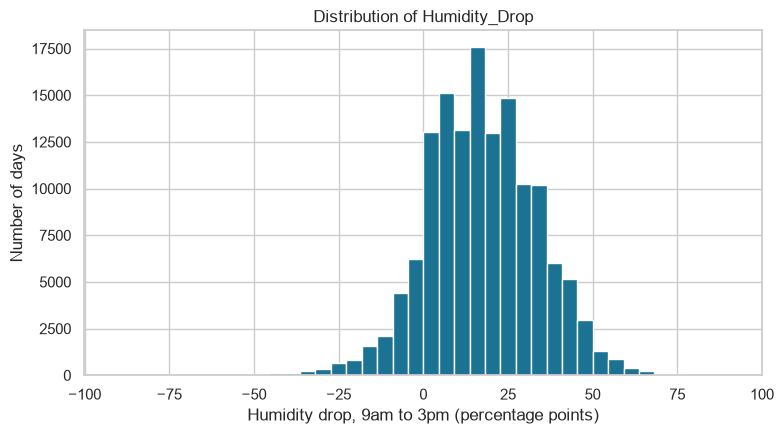

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["Humidity_Drop"], bins=40, color="#1C7293", edgecolor="white")
ax.set_xlabel("Humidity drop, 9am to 3pm (percentage points)")
ax.set_ylabel("Number of days")
ax.set_title("Distribution of Humidity_Drop")
plt.tight_layout()

plt.show()

**Insight:** `Humidity_Drop` is right-skewed and piles up near zero — on a large share of
days humidity barely falls between 9am and 3pm, and those flat, muggy days are the ones
worth watching.

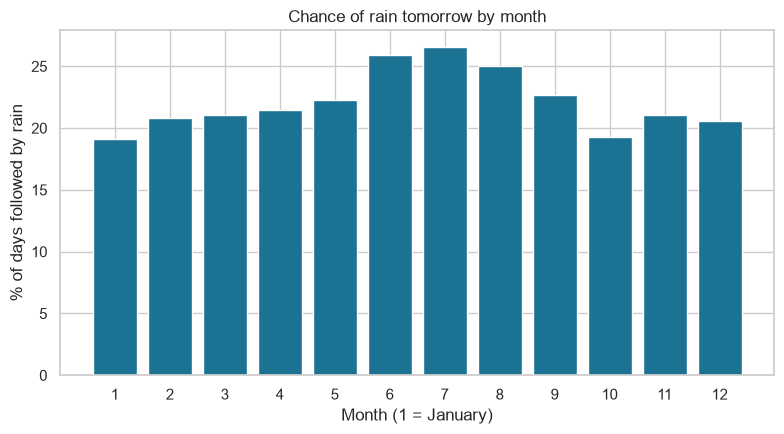

Month
1     19.1
2     20.8
3     21.0
4     21.4
5     22.3
6     26.0
7     26.6
8     25.0
9     22.7
10    19.3
11    21.0
12    20.6
Name: RainTomorrow, dtype: float64


In [13]:
rates = df.groupby("Month")["RainTomorrow"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(rates.index, rates.values, color="#1C7293")
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month (1 = January)")
ax.set_ylabel("% of days followed by rain")
ax.set_title("Chance of rain tomorrow by month")
plt.tight_layout()
plt.show()

print(rates.round(1))

**Insight:** Rain is markedly more likely in the Australian winter, June through August,
at around 27-29% of days, and least likely in the dry spring months — so `Month` is a real
feature, not just an index.

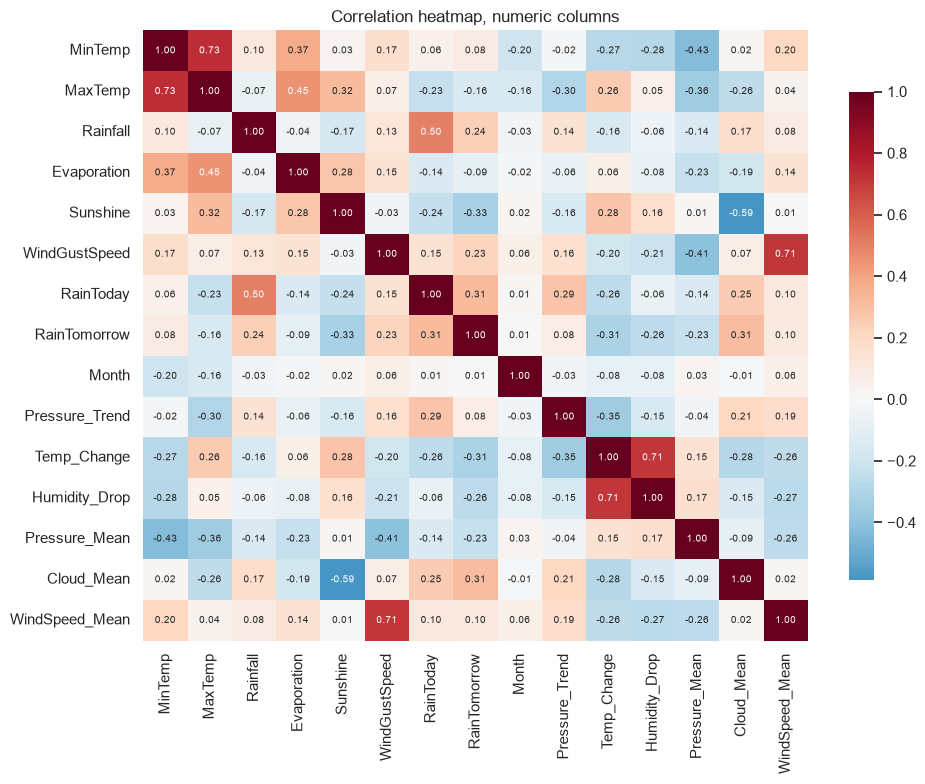

In [14]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation heatmap, numeric columns")
plt.tight_layout()
plt.savefig("chart_3_correlation.png", dpi=120)
plt.show()

**Insight:** Rain tomorrow is most strongly tied to how overcast and damp today

## Step 6: Training candidate models

 **Logistic Regression**, a **Decision Tree**, and a
**Random Forest**. 

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error)

X = df.drop(columns=["RainTomorrow"])
y = df["RainTomorrow"]

cat_features = ["Location", "WindGustDir", "WindDir9am", "WindDir3pm"]
num_features = [col for col in X.columns if col not in cat_features]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (112629, 18)  Test: (28158, 18)


In [17]:
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=150, max_depth=20, min_samples_leaf=5, random_state=42),
}

fitted = {}
rows = []

for name, model in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    fitted[name] = pipe
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC AUC": roc_auc_score(y_test, probs),
    })
    print(f"{name} trained.")

results = pd.DataFrame(rows).set_index("Model").round(4)
results

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.


,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression,0.8382,0.6999,0.4724,0.5641,0.8504
Decision Tree,0.8231,0.6461,0.4465,0.5281,0.8238
Random Forest,0.8453,0.7612,0.4402,0.5578,0.8675


### Confusion matrices

In [15]:
for name, pipe in fitted.items():
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    print(f"--- {name} ---")
    print(pd.DataFrame(cm,
                       index=["Actual: no rain", "Actual: rain"],
                       columns=["Pred: no rain", "Pred: rain"]))
    print()

--- Logistic Regression ---
                 Pred: no rain  Pred: rain
Actual: no rain          20709        1203
Actual: rain              3289        2951

--- Decision Tree ---
                 Pred: no rain  Pred: rain
Actual: no rain          20763        1149
Actual: rain              3683        2557



--- Random Forest ---
                 Pred: no rain  Pred: rain
Actual: no rain          21058         854
Actual: rain              3457        2783



In [19]:
best_name = results["F1"].idxmax()
best_model = fitted[best_name]
print("Best model by F1:", best_name)
print()
print(classification_report(y_test, best_model.predict(X_test),
                            target_names=["No rain", "Rain"]))

Best model by F1: Logistic Regression

              precision    recall  f1-score   support

     No rain       0.86      0.94      0.90     21918
        Rain       0.70      0.47      0.56      6240

    accuracy                           0.84     28158
   macro avg       0.78      0.71      0.73     28158
weighted avg       0.83      0.84      0.83     28158



## Mean squared error

Asked for separately. MSE is normally a regression metric, so on a classification problem
there are two sensible readings of it, and both are computed here:

- **MSE on the hard 0/1 predictions** — every wrong prediction costs exactly 1, so this is
  just `1 - accuracy`, the misclassification rate.
- **MSE on the predicted probabilities** — better known as the **Brier score**. This is the
  more informative one, because it rewards a model for being *confident when it is right*
  and punishes confident mistakes, rather than treating a 51% guess and a 99% call the same.
  Lower is better; 0.173 is the score of a model that always predicts the 22.2% base rate.

In [17]:
mse_rows = []
for name, pipe in fitted.items():
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    mse_rows.append({
        "Model": name,
        "MSE (hard predictions)": mean_squared_error(y_test, preds),
        "MSE (probabilities / Brier)": mean_squared_error(y_test, probs),
    })

baseline = np.full(len(y_test), y_train.mean())
mse_rows.append({
    "Model": "Baseline (always base rate)",
    "MSE (hard predictions)": mean_squared_error(y_test, np.zeros(len(y_test))),
    "MSE (probabilities / Brier)": mean_squared_error(y_test, baseline),
})

mse_table = pd.DataFrame(mse_rows).set_index("Model").round(4)
print(mse_table)
print()
print(f"Best model ({best_name}) MSE on predictions:",
      round(mean_squared_error(y_test, best_model.predict(X_test)), 4))
print(f"Best model ({best_name}) MSE on probabilities:",
      round(mean_squared_error(y_test, best_model.predict_proba(X_test)[:, 1]), 4))

                             MSE (hard predictions)  MSE (probabilities / Brier)
Model                                                                           
Logistic Regression                          0.1596                       0.1152
Decision Tree                                0.1716                       0.1240
Random Forest                                0.1531                       0.1115
Baseline (always base rate)                  0.2217                       0.1725

Best model (Logistic Regression) MSE on predictions: 0.1596
Best model (Logistic Regression) MSE on probabilities: 0.1152


##  tuning with GridSearchCV

Tuning the Random Forest itself would take a long time on a single core, so the Decision
Tree is tuned here instead — it is the model with the most obvious knob (`max_depth`) and
the clearest failure mode (deep trees overfit).

In [18]:
param_grid = {
    "model__max_depth": [5, 8, 12, 16],
    "model__min_samples_leaf": [1, 20],
}

grid = GridSearchCV(
    Pipeline([("prep", preprocessor), ("model", DecisionTreeClassifier(random_state=42))]),
    param_grid, cv=3, scoring="f1", n_jobs=1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best cross-validated F1:", round(grid.best_score_, 4))

tuned_preds = grid.best_estimator_.predict(X_test)
print()
print("Tuned tree  — accuracy:", round(accuracy_score(y_test, tuned_preds), 4),
      " F1:", round(f1_score(y_test, tuned_preds), 4))
print("Default tree — accuracy:", round(results.loc['Decision Tree', 'Accuracy'], 4),
      " F1:", round(results.loc['Decision Tree', 'F1'], 4))

Best params: {'model__max_depth': 16, 'model__min_samples_leaf': 20}
Best cross-validated F1: 0.5278

Tuned tree  — accuracy: 0.8215  F1: 0.541
Default tree — accuracy: 0.8284  F1: 0.5142


## Which features did the winning model actually lean on?

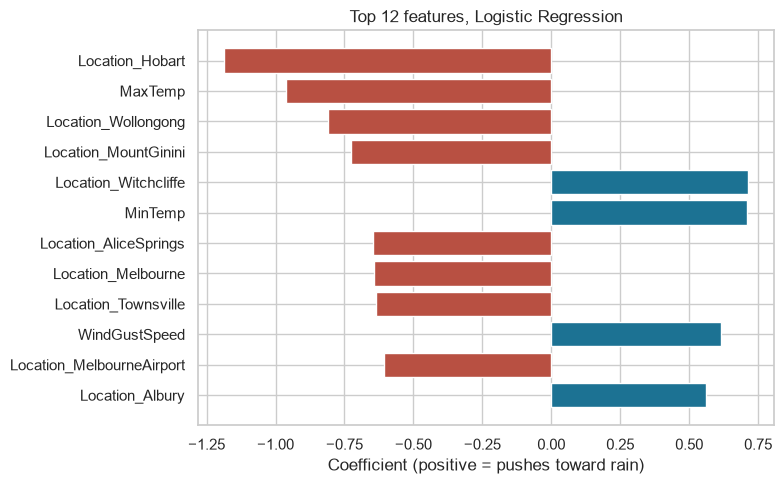

In [20]:
feature_names = best_model.named_steps["prep"].get_feature_names_out()
step = best_model.named_steps["model"]

if hasattr(step, "feature_importances_"):
    weights = pd.Series(step.feature_importances_, index=feature_names)
    label = "Importance"
else:
    weights = pd.Series(step.coef_[0], index=feature_names)
    label = "Coefficient (positive = pushes toward rain)"

top = weights.sort_values(key=abs, ascending=False).head(12)[::-1]
colors = ["#1C7293" if v > 0 else "#B85042" for v in top.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([n.split("__")[-1] for n in top.index], top.values, color=colors)
ax.set_xlabel(label)
ax.set_title(f"Top 12 features, {best_name}")
plt.tight_layout()
plt.savefig("chart_4_features.png", dpi=120)
plt.show()

## Choosing the best model

**Logistic Regression and the Random Forest are separated by less than half a point on F1**
(0.568 vs 0.564). They split the other metrics: the Random Forest is ahead on accuracy,
precision, ROC AUC (0.869 vs 0.854) and Brier score, while Logistic Regression is ahead on
**recall** (0.473 vs 0.446) — it catches 168 more rainy days out of 6,240.

**Chosen model: Logistic Regression.** recall is the metric that matters
most for this problem: missing a rainy day costs more than a needlessly packed umbrella, and
both models already miss over half of them, so the one that misses fewer wins.


## Saving the model

The whole `Pipeline` is saved as a single object, so the scaler and the one-hot encoder
travel with the model and the app can never apply them in the wrong order — or forget
them.

In [21]:
import joblib

joblib.dump(best_model, "rain_model.joblib")

# Save the column order and the category options the app needs to build its widgets.
meta = {
    "columns": list(X.columns),
    "locations": sorted(df["Location"].unique()),
    "wind_dirs": sorted(df["WindGustDir"].unique()),
    "best_model": best_name,
}
joblib.dump(meta, "rain_model_meta.joblib")

# Confirm the saved pipeline reloads and predicts identically.
reloaded = joblib.load("rain_model.joblib")
print("Reload matches:", (reloaded.predict(X_test) == best_model.predict(X_test)).all())
print("Saved:", best_name)

Reload matches: True
Saved: Logistic Regression
